In [ ]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import RobustScaler,PowerTransformer,OrdinalEncoder

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense,Dropout

from tensorflow.keras.optimizers import Adam , SGD

from tensorflow.keras.callbacks import EarlyStopping , ModelCheckpoint

from tensorflow.keras.regularizers import L1,L2

from kerastuner.tuners import RandomSearch

from tensorflow import keras

import tensorflow as tf


features = pd.read_csv(r"C:/Users/Admin/Downloads/New folder (2)/elliptic_bitcoin_dataset/elliptic_txs_features.csv", header=None)

features.columns = ['txId', 'time_step'] + [f'f{i}' for i in range(165)]


classes = pd.read_csv(r"C:/Users/Admin/Downloads/New folder (2)/elliptic_bitcoin_dataset/elliptic_txs_classes.csv")


edges = pd.read_csv(r"C:/Users/Admin/Downloads/New folder (2)/elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv")


df = pd.merge(features, classes, on='txId')


df_labeled = df[df['class'] != 'unknown'].copy()

df_labeled['class'] = df_labeled['class'].map({'1': 1, '2': 0})


df.head()


In [ ]:
# =====================
# Data preprocessing
# =====================

# Keep only labeled samples
df_labeled = df[df['class'] != 'unknown'].copy()
df_labeled['class'] = df_labeled['class'].map({'1': 1, '2': 0})

# Build X/y (use f0..f164 + time_step)
feature_cols = [c for c in df_labeled.columns if c.startswith('f')] + ['time_step']
X = df_labeled[feature_cols].copy()
y = df_labeled['class'].astype(int).values

# Replace inf with NaN and coerce to numeric
X = X.replace([np.inf, -np.inf], np.nan)
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Impute missing values (median)
medians = X.median(numeric_only=True)
X = X.fillna(medians)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (fit scaler on train only)
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Keras-ready arrays
X_train_final = X_train_scaled.astype(np.float32)
X_test_final = X_test_scaled.astype(np.float32)

print('X_train_final shape:', X_train_final.shape)
print('X_test_final shape :', X_test_final.shape)
print('Class distribution (train):', np.bincount(y_train))
print('Class distribution (test) :', np.bincount(y_test))


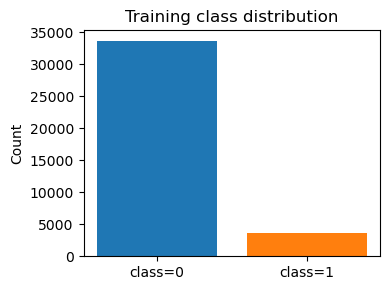

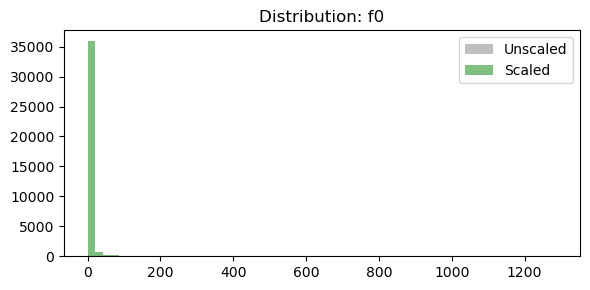

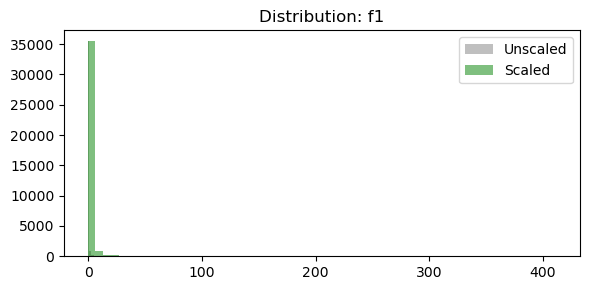

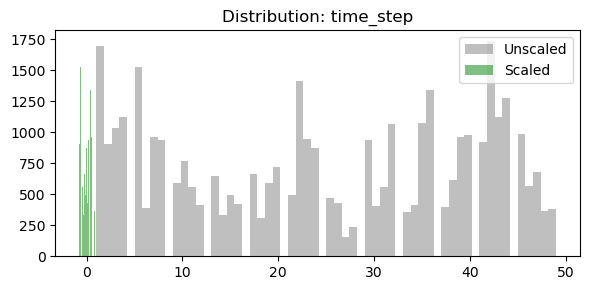

In [5]:
# =====================
# Data visualization
# =====================

import numpy as np
import matplotlib.pyplot as plt

# Class distribution
counts = np.bincount(y_train)
plt.figure(figsize=(4,3))
plt.bar(['class=0','class=1'], counts, color=['tab:blue','tab:orange'])
plt.title('Training class distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Distribution of a few selected features (before/after scaling)
selected = [feature_cols[0], feature_cols[1], feature_cols[-1]]
for feat in selected:
    idx = feature_cols.index(feat)
    plt.figure(figsize=(6,3))
    plt.hist(X_train[feat], bins=60, alpha=0.5, label='Unscaled', color='gray')
    plt.hist(X_train_scaled[:, idx], bins=60, alpha=0.5, label='Scaled', color='green')
    plt.title(f'Distribution: {feat}')
    plt.legend()
    plt.tight_layout()
    plt.show()


In [8]:


in_degree = edges.groupby('txId2').size().reset_index(name='in_degree')
in_degree.columns = ['txId', 'in_degree']

# Out-Degree: كم مرة أرسلت هذه المعاملة بيتكوين (ظهرت في عمود 'txId1')
out_degree = edges.groupby('txId1').size().reset_index(name='out_degree')
out_degree.columns = ['txId', 'out_degree']

# 3. ميزة متقدمة: هل المعاملة مرتبطة بعقد مشبوهة؟
# أولاً: نحدد أرقام المعاملات التي نعرف أنها احتيالية (Class 1)
illicit_ids = classes[classes['class'] == '1']['txId'].values

# نتحقق من الروابط: هل المعاملة أرسلت إلى (أو استقبلت من) معاملة احتيالية؟
edges['is_to_illicit'] = edges['txId2'].isin(illicit_ids).astype(int)
edges['is_from_illicit'] = edges['txId1'].isin(illicit_ids).astype(int)

# حساب عدد الجيران المشبوهين لكل معاملة
illicit_neighbors = edges.groupby('txId1')['is_to_illicit'].sum().reset_index(name='num_illicit_targets')
illicit_neighbors.columns = ['txId', 'num_illicit_targets']

# 4. دمج كل هذه الميزات الجديدة في جدول واحد
graph_features = pd.merge(in_degree, out_degree, on='txId', how='outer')
graph_features = pd.merge(graph_features, illicit_neighbors, on='txId', how='outer')

# ملء القيم الفارغة بـ 0 (لأن المعاملة التي لم تظهر في الروابط تعني أن درجتها 0)
graph_features.fillna(0, inplace=True)

# 5. الدمج النهائي مع جدول الميزات الأصلي (الـ 166 ميزة)
# افترضي أن df_labeled هو الجدول الذي جهزناه في الخطوة السابقة
df_final = pd.merge(df_labeled, graph_features, on='txId', how='left')
df_final.fillna(0, inplace=True)

print(df_final[['txId', 'in_degree', 'out_degree', 'num_illicit_targets']].head())
 

        txId  in_degree  out_degree  num_illicit_targets
0  232438397      160.0         1.0                  0.0
1  232029206       59.0         1.0                  0.0
2  232344069        0.0         2.0                  0.0
3   27553029        1.0         1.0                  0.0
4    3881097        1.0         1.0                  0.0


In [ ]:

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. تقسيم البيانات بناءً على الوقت (Time-based Split)
# التدريب: من الخطوة 1 إلى 34
# الاختبار: من الخطوة 35 إلى 49
train_df = df_final[df_final['time_step'] <= 34]
test_df = df_final[df_final['time_step'] > 34]

# تحديد الميزات (X) والهدف (y)
# نستبعد txId و time_step و class من الميزات
X_train = train_df.drop(columns=['txId', 'time_step', 'class'])
y_train = train_df['class']

X_test = test_df.drop(columns=['txId', 'time_step', 'class'])
y_test = test_df['class']

# 2. معالجة عدم التوازن (Handling Imbalance)
# نحسب نسبة القانوني إلى الاحتيالي لإعطاء وزن أكبر للاحتيال
ratio = float(y_train.value_counts()[0] / y_train.value_counts()[1])

# 3. بناء وتدريب نموذج XGBoost
model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=ratio, # ميزة قوية للتعامل مع قلة حالات الاحتيال
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

print("بدء تدريب النموذج...")
model.fit(X_train, y_train)
print("تم التدريب بنجاح!")

# 4. التنبؤ والتقييم
y_pred = model.predict(X_test)

# طباعة تقرير الأداء
print("\n--- تقرير أداء النموذج (Classification Report) ---")
print(classification_report(y_test, y_pred, target_names=['Licit (0)', 'Illicit (1)']))

# 5. رسم مصفوفة الارتباك (Confusion Matrix)
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Fraud Detection')
plt.show()

# 6. أهم الميزات (Feature Importance)
# لنرى هل ميزات الرسم البياني التي أضفناها كانت مفيدة؟
plt.figure(figsize=(10, 8))
importances = pd.Series(model.feature_importances_, index=X_train.columns)
importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 Important Features')
plt.show()


In [ ]:

import torch
from torch_geometric.data import Data

# تحويل المعاملات إلى أرقام متسلسلة (Mapping) لأن PyG يحتاج العقد من 0 إلى N
node_map = {j: i for i, j in enumerate(df_final['txId'].values)}

# تحويل الروابط (Edges) باستخدام الخريطة الجديدة
edge_index = edges.copy()
edge_index['txId1'] = edge_index['txId1'].map(node_map)
edge_index['txId2'] = edge_index['txId2'].map(node_map)

# حذف الروابط التي لا توجد لها عقد في بياناتنا (إذا وجدت)
edge_index = edge_index.dropna()
edge_index = torch.tensor(edge_index[['txId1', 'txId2']].values.t(), dtype=torch.long)

# تجهيز الميزات (X) والهدف (y)
x = torch.tensor(df_final.drop(columns=['txId', 'time_step', 'class']).values, dtype=torch.float)
y = torch.tensor(df_final['class'].values, dtype=torch.long)

# إنشاء كائن البيانات الخاص بـ PyG
data = Data(x=x, edge_index=edge_index, y=y)

# تحديد أقنعة التدريب والاختبار (Masks) بناءً على الوقت
train_mask = torch.tensor(df_final['time_step'] <= 34, dtype=torch.bool)
test_mask = torch.tensor(df_final['time_step'] > 34, dtype=torch.bool)


In [ ]:
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GCN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, output_dim)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        
        # الطبقة الأولى + تفعيل ReLU + Dropout لمنع الـ Overfitting
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        
        # الطبقة الثانية (المخرجات)
        x = self.conv2(x, edge_index)
        
        return F.log_softmax(x, dim=1)

# إنشاء النموذج
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GCN(input_dim=data.num_node_features, hidden_dim=64, output_dim=2).to(device)
data = data.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)


In [ ]:
def train():
    model.train()
    optimizer.zero_grad()
    out = model(data)
    # استخدام وزن أكبر للفئة 1 (الاحتيال) في الـ Loss Function
    loss = F.nll_loss(out[train_mask], data.y[train_mask], weight=torch.tensor([1.0, 10.0]).to(device))
    loss.backward()
    optimizer.step()
    return loss.item()

for epoch in range(1, 201):
    loss = train()
    if epoch % 20 == 0:
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}')

print("تم تدريب الـ GNN بنجاح!")


In [ ]:
model.eval()
with torch.no_grad():
    probs = torch.exp(model(data))[:, 1].cpu().numpy()
    df_final['risk_score'] = probs
